TimeSeries_ARIMA

In [5]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
%matplotlib inline


In [8]:
data = pd.read_csv("daily_minimum_temperatures.csv", sep=",")
print(data.shape)
data.head()

(3650, 2)


,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


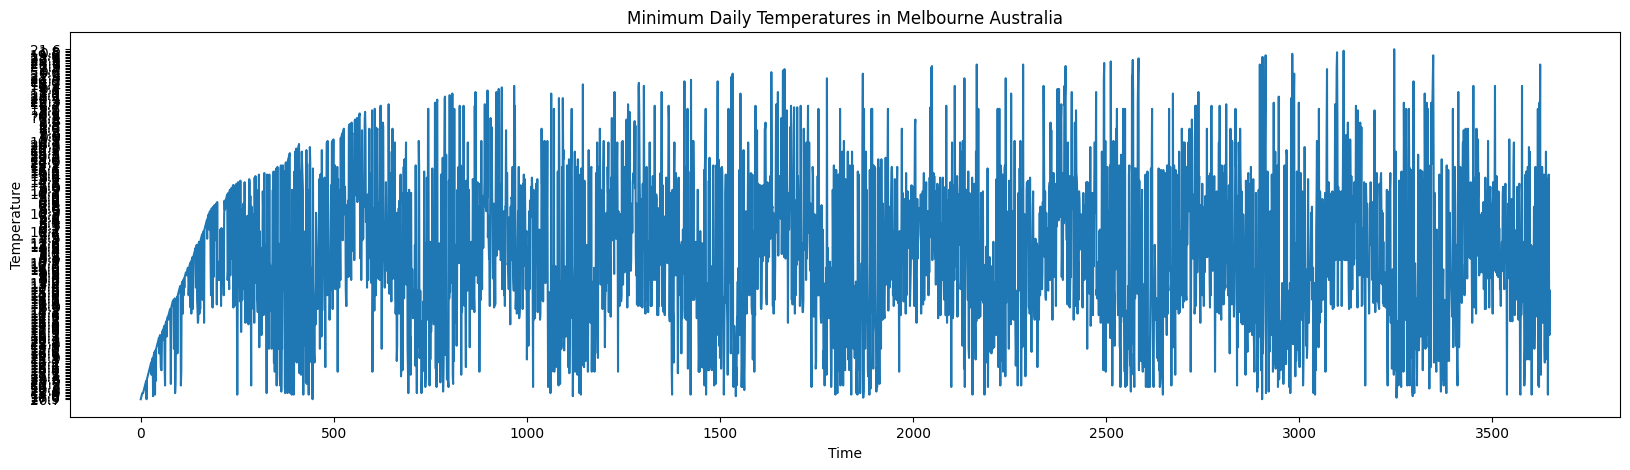

In [12]:
plt.figure(figsize=(20, 5))
plt.plot(data.iloc[:, 1])
plt.title("Minimum Daily Temperatures in Melbourne Australia")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

In [13]:
train_percentage = 0.67
train_size = int(len(data) * train_percentage)

train = data[:train_size]
test = data[train_size:]

print(train.shape)
train.head()

(2445, 2)


,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [15]:
# ARIMA(p,d,q)
# p: The number of lag observations included in the model, also called the lag order.
# d: The number of times that the raw observations are differenced, also called the degree of differencing.
# q: The size of the moving average window, also called the order of moving average.

# He cambiado train.Temp por train['Temp'] para evitar el error de atributo
temp_col = train.columns[1]  # actual temperature column name in your CSV
train_temp = pd.to_numeric(train[temp_col], errors='coerce').dropna()
model = ARIMA(train_temp, order=(5, 1, 2))

# En versiones nuevas de statsmodels, usa simplemente .fit()
results = model.fit() 

# Si el código de tu curso es muy viejo y falla, intenta:
# results = model.fit(disp=0)

c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [16]:
results.forecast(4)

c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


2442    9.053083
2443    8.335718
2444    8.154364
2445    8.160089
Name: predicted_mean, dtype: float64

In [17]:
index_start = len(train)
index_end = len(train) + len(test)

# En el nuevo ARIMA, solo pasas el número de pasos a predecir
# steps = len(test)
predictions = results.get_forecast(steps=len(test))
pred_values = predictions.predicted_mean
conf_int = predictions.conf_int()

c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


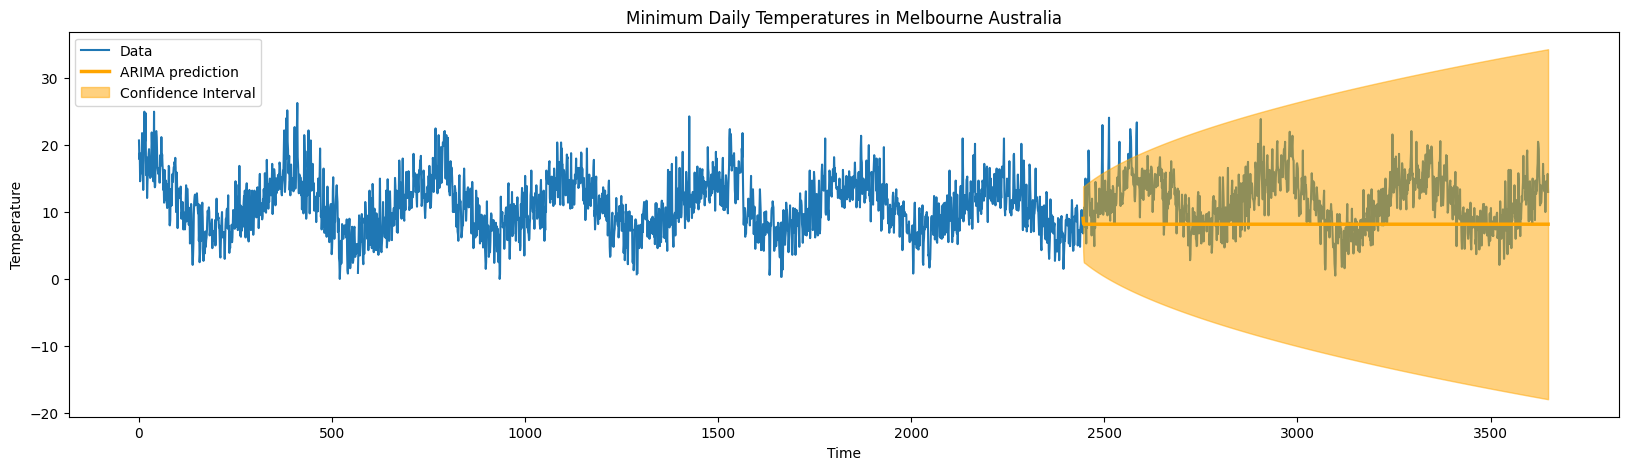

In [28]:
# Definir los índices para el eje X de las predicciones
x_axis = range(index_start, index_end)

plt.figure(figsize=(20, 5))

# 1. Graficar datos originales
plt.plot(pd.to_numeric(data[temp_col], errors='coerce'), label="Data", zorder=1)

# 2. Graficar predicción (Ajustado a la nueva API)
plt.plot(x_axis, pred_values, label="ARIMA prediction", zorder=2, color="orange", linewidth=2.5)

# 3. Graficar intervalo de confianza (el sombreado)
plt.fill_between(x_axis, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], 
                 color='orange', alpha=0.5, label="Confidence Interval")

plt.title("Minimum Daily Temperatures in Melbourne Australia")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()

In [31]:
y_true = pd.to_numeric(test[temp_col], errors='coerce').reset_index(drop=True)
y_pred = pred_values.reset_index(drop=True)
mask = y_true.notna() & y_pred.notna()
mse = mean_squared_error(y_true[mask], y_pred[mask])
print(mse)

27.715214726441793
